In [1]:
!pip install -Uqq graphviz fastbook

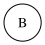

In [2]:
import graphviz
graphviz.Source("""digraph {
box [label = B, shape = circle]
}""")

# graphviz.Digraph('''program[shape=box3d width=2 height=1] 
# inputs->program->results''')


In [3]:
?graphviz

Type:        module
String form: <module 'graphviz' from '/opt/conda/envs/fastbook/lib/python3.13/site-packages/graphviz/__init__.py'>
File:        /opt/conda/envs/fastbook/lib/python3.13/site-packages/graphviz/__init__.py
Docstring:  
Assemble DOT source code and render it with Graphviz.

Example:
    >>> import graphviz  # doctest: +NO_EXE
    >>> dot = graphviz.Digraph(comment='The Round Table')

    >>> dot.node('A', 'King Arthur')
    >>> dot.node('B', 'Sir Bedevere the Wise')
    >>> dot.node('L', 'Sir Lancelot the Brave')

    >>> dot.edges(['AB', 'AL'])

    >>> dot.edge('B', 'L', constraint='false')

    >>> print(dot)  #doctest: +NORMALIZE_WHITESPACE
    // The Round Table
    digraph {
        A [label="King Arthur"]
        B [label="Sir Bedevere the Wise"]
        L [label="Sir Lancelot the Brave"]
        A -> B
        A -> L
        B -> L [constraint=false]
    }

In [4]:
dir(graphviz)

['CalledProcessError',
 'DOT_BINARY',
 'Digraph',
 'DotSyntaxWarning',
 'ENGINES',
 'ExecutableNotFound',
 'FORMATS',
 'FORMATTERS',
 'FileExistsError',
 'FormatSuffixMismatchWarning',
 'Graph',
 'RENDERERS',
 'RequiredArgumentError',
 'SUPPORTED_JUPYTER_FORMATS',
 'Source',
 'UNFLATTEN_BINARY',
 'UnknownSuffixWarning',
 '__all__',
 '__author__',
 '__builtins__',
 '__cached__',
 '__copyright__',
 '__doc__',
 '__file__',
 '__license__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__title__',
 '__version__',
 '_compat',
 '_defaults',
 '_tools',
 'backend',
 'base',
 'copying',
 'dot',
 'encoding',
 'escape',
 'exceptions',
 'graphs',
 'jupyter_integration',
 'nohtml',
 'parameters',
 'pipe',
 'pipe_lines',
 'pipe_lines_string',
 'pipe_string',
 'piping',
 'quoting',
 'render',
 'rendering',
 'saving',
 'set_default_engine',
 'set_default_format',
 'set_jupyter_format',
 'sources',
 'unflatten',
 'unflattening',
 'version',
 'view']

X - random variable; a realization of random process (risk factor)

Y - payoff function; $Y \sim h(x, w)$

State {X, Y, Z}; $Z = \frac{\delta Y}{\delta X}$


Conditional expectation `E[Y|X]` for two descrete random variables Y and X is given by 
$$E[Y|X] = \frac{\sum_{x} x P(X=x, Y=y)}{P(y)}$$

**Goal**: find a predictor $\overset{\wedge}{Y} = g(X)$ to minimise $E[(Y-\overset{\wedge}{Y})^2]$ (LMSE optimization) 

**Res**: A predictor is predictor is $g(X) = E[Y|X]$

**Methods**

* DML - differential machine learning method
* LRM - likelyhood ratio method

**Training**
* historical data
* simulated data


In [23]:
#The main routine that calculates the payoff from the sample
#asset paths, and computes the price of the call and put options.
#It also prints out the price of call and put options using the
# Black-Scholes formula with the same parameters.
S0 = 100 # Initial value of stock
mu = .05 # Drift rate of the return, should be the same as the risk-free interest rate
sigma = .12 # Standard deviation of the periodic return
TPeriod = 2 # Time period in year
num_path = 2048 # Number of asset paths for the simulation
step_length = 1/255 # Time length of one step inside a period We are using 255 steps
int_rate= .05 # Risk-free interest rate
strike = 125 # Strike price

In [24]:
from scipy.stats import norm
import numpy as np
# --- Black-Scholes Formula ---
def blsprice(S0, K, r, T, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

    return call, put

bs_call, bs_put = blsprice(S0, strike, int_rate, TPeriod, sigma)

print("BS Call:", bs_call)
print("BS Put:", bs_put)

BS Call: 2.4635682302591384
BS Put: 15.568245484754073


$d S_t=μ S_t​dt+σS_t​dW_t$

$S_t=S_0​e^{(μ−\frac{1}{2}​σ^2)t+σW_t)}$

In [25]:
import numpy as np 
import math
from scipy.stats import qmc, norm


def simulate_asset_path(sigma, TPeriod, num_path, S0, mu, step_length):
    num_step = math.ceil(TPeriod / step_length)
    print(f"{num_step =}")

    #Z = np.random.randn(num_step, num_path)
    # variance reduction by antitheties
    #Z = np.random.randn(num_step, num_path//2)
    #Z = np.hstack([Z, -Z])

    Z = norm.ppf(
    qmc.Sobol(d=num_step, scramble=True)
       .random(n=num_path // 2)).T
    
    Z = np.hstack([Z, -Z])
    print(f"{Z =}")
    W = np.cumsum(Z, axis=0) * np.sqrt(step_length)

    t = step_length * np.arange(1, num_step + 1)
    drift = (mu - 0.5 * sigma**2) * t[:, None]

    S = S0 * np.exp(drift + sigma * W)

    # prepend S0
    S = np.vstack([np.full((1, num_path), S0), S])
    time = np.concatenate([[0], t])

    return S, time


[sample, time] = simulate_asset_path(sigma,TPeriod,num_path,S0,mu,step_length);

num_step =510
Z =array([[ 1.57797276, -2.43147594, -0.51277276, ...,  0.5141488 ,
         2.50856941, -1.57354246],
       [ 0.31438003, -0.62944171,  1.08804809, ...,  0.63256709,
        -1.08329286,  2.89963686],
       [ 0.21450548, -0.72034686,  1.15230118, ...,  0.37521478,
        -0.06639968,  0.89942236],
       ...,
       [-1.24562287,  0.53706287, -0.14169368, ..., -1.02705903,
         1.21367025, -0.53173686],
       [ 1.41057451, -0.61729277,  0.6427827 , ..., -0.02098142,
         0.0392551 , -0.96190028],
       [-0.09567556,  1.57728143, -0.86350396, ...,  0.14518609,
        -0.50872492,  0.79463051]], shape=(510, 2048))


In [26]:
ST = sample[-1]
K = strike
r = int_rate
T = TPeriod
payoff = np.maximum(ST - K, 0)
expected_payoff = np.mean(payoff)
price = np.exp(-r * T) * expected_payoff

put_payoff = np.maximum(K - ST, 0)
put_expected_payoff = np.mean(put_payoff)
put_price = np.exp(-r * T) * put_expected_payoff

display(payoff)
display(expected_payoff)
display(price)

display(put_price)

array([ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
       20.665986], shape=(2048,))

np.float64(2.8731462473265976)

np.float64(2.599730232070705)

np.float64(15.63187290864806)

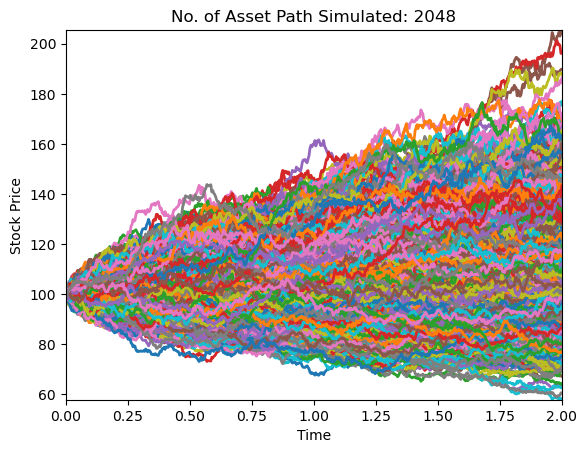

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Plot ---
plt.figure(facecolor='white')
plt.plot(time, sample, linewidth=2)
plt.axis([time[0], time[-1], np.min(sample), np.max(sample)])
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title(f'No. of Asset Path Simulated: {sample.shape[1]}')
plt.show()

In [ ]:
graphviz.Source('''
graph ConditionalProbability {
    layout=neato
    overlap=true
    splines=false

    node [
        fontsize=14
    ]

    A [shape=circle, fixedsize=true, width=3, pos="0,0!", label="A"]
    B [shape=circle, fixedsize=true, width=3, pos="1.6,0!", label="B"]

    AB [
        shape=ellipse,
        style=filled,
        fillcolor=lightblue,
        width=1.2,
        height=2,
        pos="0.8,0!",
        label="A ∩ B"
    ]
}

''')
